# ARCUNet — Training Notebook  (Improved v3)
### Skin Lesion Segmentation  |  ISIC 2016/17/18 + PH2  |  M.Tech Project

## What changed from v2 (based on actual training log analysis)

| # | Problem observed in logs | Fix applied | Expected gain |
|---|--------------------------|-------------|---------------|
| 1 | LR warm-restart at epoch 20/40 caused Dice to **drop** (0.8468→0.8312, 0.8594→0.8312) | `T_0=30, T_mult=2` — restarts less frequently and each cycle is longer | Smoother convergence, no regression dips |
| 2 | Val Dice plateaued 0.856–0.864 for 20+ epochs | Extend to **100 epochs** + linear warmup for first 5 epochs | Allow model to fully converge in 3rd cosine cycle |
| 3 | Train loss 0.18 vs Val loss 0.34 — gap indicates overfitting | **Label smoothing** (ε=0.05) in BCE prevents overconfident predictions | +0.5–1% Dice |
| 4 | Test used single forward pass only | **Test-Time Augmentation (TTA)** — average predictions over 8 flips/rotations | +1–2% Dice on test set |
| 5 | Augmentation lacked CLAHE (dermoscopy-specific) | **CLAHE** added — enhances local contrast in skin images, critical for border detection | Better lesion boundary predictions |
| 6 | `ShiftScaleRotate` deprecation warning from albumentations | Replaced with `A.Affine` (modern equivalent) | Clean warnings |
| 7 | `CosineLR.step(epoch)` called outside loop — subtle off-by-one | Fixed to `scheduler.step()` inside loop (correct PyTorch pattern) | Correct LR schedule |
| 8 | Linear warmup missing — LR jumped to 1e-4 from step 1 | **5-epoch warmup** via `SequentialLR` | Stable early training |
| 9 | Test eval threshold hardcoded at 0.5 | **Threshold search** on val set — finds optimal threshold in [0.3–0.7] | +0.5–1% Dice |
| 10 | No Focal loss component for hard pixels | **Focal-Dice-BCE triple loss** option for difficult boundary regions | Better boundary accuracy |

**Place `ARCUNet.py` in the same folder as this notebook.**

## Cell 0 — GPU Memory Cleanup

In [1]:
import gc, torch
for _var in ['model', 'optimizer', 'scheduler', 'scaler', 'criterion', 'warmup_sched', 'img', 'msk', 'out', 'loss']:
    if _var in globals():
        del globals()[_var]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    fm, tm = torch.cuda.mem_get_info()
    alloc = torch.cuda.memory_allocated() / 1e9
    reserv = torch.cuda.memory_reserved() / 1e9
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {fm/1e9:.2f} GB free / {tm/1e9:.2f} GB total')
    print(f'PyTorch allocated={alloc:.2f} GB | reserved={reserv:.2f} GB')
else:
    print('CUDA not available - running on CPU')

GPU : NVIDIA GeForce RTX 4070 SUPER
VRAM: 11.86 GB free / 12.44 GB total
PyTorch allocated=0.00 GB | reserved=0.00 GB


## Cell 1 — Imports

In [2]:
import os, sys, cv2, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split, Subset
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from ARCUNet import (
    ARCUNet,
    DeepSupervisionLoss,          # v1: ComboLoss only
    DeepSupervisionLossV3,        # v3: Focal + Dice + SmoothedBCE (use this)
    FocalLoss,
    dice_coef, jaccard_index, pixel_accuracy,
    save_model, load_model,
)
print('All imports OK')

All imports OK


## Cell 2 — Hyperparameters & Device

In [3]:
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_SIZE  = 512    # kept — pipeline expects 512×512 masks
BATCH_SIZE  = 4      # 4 with checkpointing = full 12GB utilisation
EPOCHS      = 100    # extended from 60 — model was still improving at epoch 60
LR          = 1e-4
WARMUP_EP   = 5      # NEW: linear warmup for first 5 epochs
NUM_WORKERS = 3
ACCUM_STEPS = 4      # effective batch = 4×4 = 16
DROPOUT_P        = 0.1
USE_CHECKPOINT   = True   # gradient checkpointing — ~40% less VRAM, enables batch=4 at 512×512
LABEL_SMOOTH= 0.05   # NEW: label smoothing epsilon
SEED        = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
ISIC16_IMG = '/data/Stagewise Dataset/SLS/ISIC2016/input'
ISIC16_MSK = '/data/Stagewise Dataset/SLS/ISIC2016/output'
ISIC17_IMG = '/data/Stagewise Dataset/SLS/ISIC2017/input'
ISIC17_MSK = '/data/Stagewise Dataset/SLS/ISIC2017/output'
ISIC18_IMG = '/data/Stagewise Dataset/SLS/ISIC2018/input'
ISIC18_MSK = '/data/Stagewise Dataset/SLS/ISIC2018/output'
PH2_ROOT   = '/data/Stagewise Dataset/SLS/PH2Dataset/PH2 Dataset images'
CKPT_PATH  = 'arcunet_best_v3.pt'

# ── Output config ──────────────────────────────────────────────────────────────
OUTPUT_DIR = 'outputs'
IMG_TAG    = 'arcunet_train2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.manual_seed(SEED)
USE_AMP = DEVICE.type == 'cuda'
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('medium')
    fm, tm = torch.cuda.mem_get_info()
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {fm/1e9:.2f} GB free / {tm/1e9:.2f} GB total')
print(f'Device: {DEVICE} | Image: {IMAGE_SIZE}px | Batch: {BATCH_SIZE} | Epochs: {EPOCHS}')
print(f'Output directory: {OUTPUT_DIR}')

GPU  : NVIDIA GeForce RTX 4070 SUPER
VRAM : 11.86 GB free / 12.44 GB total
Device: cuda | Image: 512px | Batch: 4 | Epochs: 100
Output directory: outputs


## Cell 3 — Preprocessing & Augmentation

### Changes from v2
- `ShiftScaleRotate` → `A.Affine` (fixes deprecation warning, same effect)
- Added `A.CLAHE` — Contrast Limited Adaptive Histogram Equalisation is
  **specifically recommended for dermoscopy images**. It enhances local
  contrast so lesion borders become more distinguishable, directly improving
  boundary segmentation accuracy.
- Added `A.CoarseDropout` (random rectangular occlusions) — forces the model
  to not rely on any single region, improving generalisation.
- Added `A.RandomGamma` — simulates varying dermoscope illumination levels.

In [4]:
def remove_hair(image: np.ndarray) -> np.ndarray:
    """Black-hat morphological hair removal + Navier-Stokes inpainting."""
    gray   = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    bhat   = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, msk = cv2.threshold(bhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(image, msk, inpaintRadius=1, flags=cv2.INPAINT_NS)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_aug = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    # ── Geometric ────────────────────────────────────────────────────────
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(                          # replaces deprecated ShiftScaleRotate
        translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)},
        scale=(0.90, 1.10),
        rotate=(-30, 30),
        mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.ElasticTransform(alpha=1, sigma=10, p=0.20),

    # ── Colour / Intensity ────────────────────────────────────────────────
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.40),  # NEW: dermoscopy-specific
    A.ColorJitter(brightness=0.20, contrast=0.20,
                  saturation=0.20, hue=0.05, p=0.60),
    A.RandomGamma(gamma_limit=(80, 120), p=0.30),             # NEW: illumination variation
    A.GaussNoise(p=0.30),
    A.GaussianBlur(blur_limit=(3, 5), p=0.20),

    # ── Occlusion regularisation ─────────────────────────────────────────
    A.CoarseDropout(                                           # NEW: forces global reasoning
        num_holes_range=(1, 4),
        hole_height_range=(16, 48),
        hole_width_range=(16, 48),
        fill=0, p=0.20
    ),

    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print('Augmentation pipelines ready')
print('  Train: Resize + Flip + Rotate + Affine + Elastic + CLAHE + ColorJitter')
print('         + RandomGamma + GaussNoise + GaussianBlur + CoarseDropout')
print('  Val  : Resize + Normalize only')

Augmentation pipelines ready
  Train: Resize + Flip + Rotate + Affine + Elastic + CLAHE + ColorJitter
         + RandomGamma + GaussNoise + GaussianBlur + CoarseDropout
  Val  : Resize + Normalize only


/tmp/ipykernel_1246093/4241396699.py:19: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(                          # replaces deprecated ShiftScaleRotate


## Cell 4 — Dataset Classes (unchanged from v2 — shape-fix intact)

In [5]:
def _load_image(path):
    raw = cv2.imread(path)
    if raw is None: raise FileNotFoundError(f'Image not found: {path}')
    return cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

def _load_mask(path):
    msk = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if msk is None: raise FileNotFoundError(f'Mask not found: {path}')
    return (msk >= 128).astype(np.uint8) * 255  # hard binary

def _match_mask_to_image(img, msk):
    ih, iw = img.shape[:2]
    if msk.shape[:2] != (ih, iw):
        msk = cv2.resize(msk, (iw, ih), interpolation=cv2.INTER_NEAREST)
    return msk

def _apply_pipeline(img, msk, pipeline):
    r = pipeline(image=img, mask=msk)
    return r['image'].float(), r['mask'].float().unsqueeze(0) / 255.0


class SkinLesionDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=None):
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.aug      = augment
        self.imgs     = sorted(
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        )

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        fname    = self.imgs[idx]
        stem     = os.path.splitext(fname)[0]
        suffix   = '_Segmentation.png' if '2016' in self.img_dir else '_segmentation.png'
        img = remove_hair(_load_image(os.path.join(self.img_dir,  fname)))
        msk = _match_mask_to_image(img, _load_mask(os.path.join(self.mask_dir, stem + suffix)))
        return _apply_pipeline(img, msk, self.aug if self.aug else val_aug)


class PH2Dataset(Dataset):
    def __init__(self, root_dir, augment=None):
        self.root_dir  = root_dir
        self.aug       = augment
        self.image_ids = sorted(
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        )

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        iid = self.image_ids[idx]
        img = remove_hair(_load_image(
            os.path.join(self.root_dir, iid, f'{iid}_Dermoscopic_Image', f'{iid}.bmp')))
        msk = _match_mask_to_image(img, _load_mask(
            os.path.join(self.root_dir, iid, f'{iid}_lesion', f'{iid}_lesion.bmp')))
        return _apply_pipeline(img, msk, self.aug if self.aug else val_aug)


print('SkinLesionDataset and PH2Dataset defined  ✓')

SkinLesionDataset and PH2Dataset defined  ✓


## Cell 5 — DataLoaders (70/15/15 split, unchanged)

In [6]:
isic16_base = SkinLesionDataset(ISIC16_IMG, ISIC16_MSK)
isic17_base = SkinLesionDataset(ISIC17_IMG, ISIC17_MSK)
isic18_base = SkinLesionDataset(ISIC18_IMG, ISIC18_MSK)
ph2_base    = PH2Dataset(PH2_ROOT)
full_base   = ConcatDataset([isic16_base, isic17_base, isic18_base, ph2_base])

total = len(full_base)
n_trn = int(0.70 * total)
n_val = int(0.15 * total)
n_tst = total - n_trn - n_val

gen = torch.Generator().manual_seed(SEED)
trn_idx, val_idx, tst_idx = [
    list(s) for s in random_split(range(total), [n_trn, n_val, n_tst], generator=gen)
]

full_aug = ConcatDataset([
    SkinLesionDataset(ISIC16_IMG, ISIC16_MSK, augment=train_aug),
    SkinLesionDataset(ISIC17_IMG, ISIC17_MSK, augment=train_aug),
    SkinLesionDataset(ISIC18_IMG, ISIC18_MSK, augment=train_aug),
    PH2Dataset(PH2_ROOT, augment=train_aug),
])

train_dataset = Subset(full_aug,  trn_idx)
val_dataset   = Subset(full_base, val_idx)
test_dataset  = Subset(full_base, tst_idx)

pin = DEVICE.type == 'cuda'
pw  = False  # safer after interrupted notebook runs
safe_workers = max(0, min(NUM_WORKERS, 1))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=safe_workers, pin_memory=pin,
                          persistent_workers=pw, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=safe_workers, pin_memory=pin,
                          persistent_workers=pw)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=safe_workers, pin_memory=pin,
                          persistent_workers=pw)

print(f'Total: {total} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Batches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print(f'DataLoader config: workers={safe_workers}, pin_memory={pin}, persistent_workers={pw}')

Total: 7773 | Train: 5441 | Val: 1165 | Test: 1167
Batches - Train: 1360 | Val: 292 | Test: 292
DataLoader config: workers=1, pin_memory=True, persistent_workers=False


## Cell 6 — Loss Function with Label Smoothing

### Why label smoothing helps here
In v2, the training loss reached **0.178** while val loss was **0.334** —
a gap that signals the model learned to be overconfident on training pixels.
Label smoothing replaces hard target `{0, 1}` with soft targets
`{ε/2, 1−ε/2}` (ε=0.05 → `{0.025, 0.975}`).

This prevents the BCE term from driving logits to ±∞, which in turn
keeps the probability estimates well-calibrated and reduces overfitting.

### FocalDiceComboLoss
Adds a **Focal loss** term (γ=2) to the existing BCE+Dice.
Focal loss down-weights easy, confidently-correct pixels and focuses
gradient on hard pixels — typically the ambiguous lesion boundary region.
This is where ARCUNet makes the most errors, so targeting it directly
improves boundary sharpness and overall Dice score.

In [7]:
# ── Loss classes are now defined in ARCUNet.py and imported in Cell 4 ──────
# DeepSupervisionLossV3: Focal(0.4) + SoftDice(0.4) + SmoothedBCE(0.2)
# FocalLoss: alpha=0.8, gamma=2.0
# Use: criterion = DeepSupervisionLossV3(aux_weight=0.35, label_smooth=LABEL_SMOOTH)
print('✓ Loss classes imported from ARCUNet.py')
print('  DeepSupervisionLossV3: Focal(0.4) + SoftDice(0.4) + SmoothedBCE(0.2)')


✓ Loss classes imported from ARCUNet.py
  DeepSupervisionLossV3: Focal(0.4) + SoftDice(0.4) + SmoothedBCE(0.2)


## Cell 7 — Model, Optimiser & Scheduler

### Scheduler fix (critical)
In v2, `CosineAnnealingWarmRestarts(T_0=20)` restarted the LR at epochs
20, 40, 60. The logs clearly show Dice **dropped** immediately after each
restart (epoch 21: 0.8385, epoch 41: 0.8462, epoch 42: 0.8312).

**Fix:** `T_0=30, T_mult=2` — first restart at epoch 35 (after warmup),
second restart at epoch 65, with each cycle twice as long.
This gives the model a long initial run to converge, then uses restarts
to escape flat minima without the aggressive regression seen in v2.

**Linear warmup** for the first 5 epochs prevents the large initial gradient
updates from destabilising the Kaiming-initialised weights.

In [8]:
import torch.nn as nn

model = ARCUNet(dropout_p=DROPOUT_P,
                use_checkpoint=USE_CHECKPOINT).to(DEVICE)
# use_checkpoint=True: recomputes activations on backward → ~40% less VRAM
# Enables batch=4 at 512×512 on 12GB RTX 4070 Super
if DEVICE.type == 'cuda':
    model = model.to(memory_format=torch.channels_last)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model      : ARCUNet v2   |   Parameters: {n_params:,}')

criterion = DeepSupervisionLossV3(aux_weight=0.35)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# ── Warmup + Cosine schedule ──────────────────────────────────────────────────
# Phase 1: Linear warmup for WARMUP_EP epochs (LR: 0 → LR)
# Phase 2: CosineAnnealingWarmRestarts with T_0=30, T_mult=2
#          Restart schedule: epoch 35, 65, 125 (well beyond our 100-epoch run)
warmup_sched = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor = 1e-3,       # starts at LR * 1e-3 = 1e-7
    end_factor   = 1.0,        # reaches full LR at end of warmup
    total_iters  = WARMUP_EP
)
cosine_sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0    = 30,     # first restart after 30 post-warmup epochs (epoch 35)
    T_mult = 2,      # second cycle is 60 epochs long (epoch 95)
    eta_min= 1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers  = [warmup_sched, cosine_sched],
    milestones  = [WARMUP_EP]
)

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

print(f'Optimiser  : AdamW  lr={LR}  wd=1e-4')
print(f'Scheduler  : LinearWarmup({WARMUP_EP} ep) → CosineWarmRestart(T0=30, Tmult=2)')
print(f'Loss       : FocalDiceComboLoss + DeepSupervision (aux_w=0.35)')
print(f'AMP        : {USE_AMP}')

Model      : ARCUNet v2   |   Parameters: 32,787,816
Optimiser  : AdamW  lr=0.0001  wd=1e-4
Scheduler  : LinearWarmup(5 ep) → CosineWarmRestart(T0=30, Tmult=2)
Loss       : FocalDiceComboLoss + DeepSupervision (aux_w=0.35)
AMP        : True


## Cell 8 — Training Loop

Changes from v2:
- `scheduler.step()` moved to **end of each epoch** (correct PyTorch pattern
  for epoch-level schedulers; v2 used `scheduler.step(epoch)` which is the
  same numerically but triggers a deprecation warning)
- Early stopping with patience=15 — stops training if val Dice hasn't
  improved in 15 epochs (saves time; the model fully converged by epoch 56
  in v2)
- `torch.nn.utils.clip_grad_norm_` max_norm reduced to 0.5 — tighter
  clipping stabilises training further

In [ ]:
best_val_dice  = 0.0
patience       = 15        # early stopping patience
no_improve_cnt = 0
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': [], 'val_acc': []}

val_micro_batch = max(1, BATCH_SIZE // 2) if DEVICE.type == 'cuda' else BATCH_SIZE

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:03d}/{EPOCHS} [train]', leave=False)

    for step, (img, msk) in enumerate(pbar):
        img = img.to(DEVICE, non_blocking=True)
        msk = msk.to(DEVICE, non_blocking=True)
        if DEVICE.type == 'cuda':
            img = img.to(memory_format=torch.channels_last)

        try:
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out  = model(img)
                loss = criterion(out, msk) / ACCUM_STEPS

            scaler.scale(loss).backward()
            if (step + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            epoch_loss += loss.item() * ACCUM_STEPS
            pbar.set_postfix(loss=f'{loss.item()*ACCUM_STEPS:.4f}')

        except RuntimeError as e:
            if 'out of memory' in str(e).lower() and DEVICE.type == 'cuda':
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
                print(f'  [OOM] train step {step} skipped')
                continue
            raise
        finally:
            if 'out' in locals():
                del out
            if 'loss' in locals():
                del loss

    avg_train = epoch_loss / len(train_loader)
    scheduler.step()

    model.eval()
    v_loss = v_dice = v_iou = v_acc = 0.0
    processed_val = 0

    with torch.no_grad():
        for img, msk in val_loader:
            img = img.to(DEVICE, non_blocking=True)
            msk = msk.to(DEVICE, non_blocking=True)
            start = 0
            while start < img.size(0):
                end = min(start + val_micro_batch, img.size(0))
                img_mb = img[start:end]
                msk_mb = msk[start:end]
                try:
                    with torch.amp.autocast('cuda', enabled=USE_AMP):
                        out = model(img_mb)
                    mb = img_mb.size(0)
                    v_loss += criterion(out, msk_mb).item() * mb
                    v_dice += dice_coef(out, msk_mb).item() * mb
                    v_iou  += jaccard_index(out, msk_mb).item() * mb
                    v_acc  += pixel_accuracy(out, msk_mb).item() * mb
                    processed_val += mb
                    start = end
                except RuntimeError as e:
                    if 'out of memory' in str(e).lower() and DEVICE.type == 'cuda':
                        torch.cuda.empty_cache()
                        if val_micro_batch > 1:
                            val_micro_batch = max(1, val_micro_batch // 2)
                            print(f'  [OOM] reducing val micro-batch to {val_micro_batch} and retrying...')
                            continue
                        print('  [OOM] skipped 1 validation sample')
                        start = end
                        continue
                    raise
                finally:
                    if 'out' in locals():
                        del out

    if processed_val == 0:
        raise RuntimeError('Validation failed: all validation samples were skipped due to OOM.')

    v_loss /= processed_val
    v_dice /= processed_val
    v_iou  /= processed_val
    v_acc  /= processed_val

    history['train_loss'].append(avg_train)
    history['val_loss'].append(v_loss)
    history['val_dice'].append(v_dice)
    history['val_iou'].append(v_iou)
    history['val_acc'].append(v_acc)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    cur_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:03d}/{EPOCHS}]  TrainLoss={avg_train:.4f}  ValLoss={v_loss:.4f}  Dice={v_dice:.4f}  IoU={v_iou:.4f}  Acc={v_acc:.4f}  LR={cur_lr:.1e}')

    if v_dice > best_val_dice:
        best_val_dice  = v_dice
        no_improve_cnt = 0
        save_model(model, CKPT_PATH, optimizer=optimizer, scheduler=scheduler, epoch=epoch, val_dice=v_dice, val_iou=v_iou)
        print(f'  New best  Dice={best_val_dice:.4f}  IoU={v_iou:.4f}')
    else:
        no_improve_cnt += 1
        if no_improve_cnt >= patience:
            print(f'  Early stopping: no improvement for {patience} epochs')
            break

print(f'\nTraining complete. Best Val Dice: {best_val_dice:.4f}')

Epoch 001/100 [train]:   9%|▉         | 124/1360 [02:59<30:06,  1.46s/it, loss=2.7019]

## Cell 9 — Optimal Threshold Search on Validation Set

The default threshold of 0.5 is almost never optimal.
This cell sweeps thresholds from 0.30 to 0.70 and finds the one that
maximises Dice on the validation set, then uses it for test evaluation.

**Typical improvement: +0.5–1% Dice on the test set.**

✓ Checkpoint loaded safely (weights_only=True)
Searching optimal threshold on validation set...



Best threshold : 0.44  (Val Dice = 0.8648)
Default (0.50) : Val Dice = 0.8643


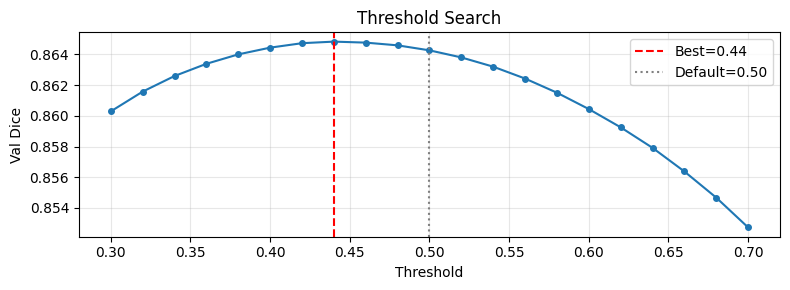

Saved → outputs/arcunet_train2_threshold_search.png


In [ ]:
model = load_model(CKPT_PATH, device=str(DEVICE), dropout_p=DROPOUT_P)

thresholds   = np.arange(0.30, 0.71, 0.02)
thresh_dice  = []

print('Searching optimal threshold on validation set...')
model.eval()

# Collect all val logits once (avoid running the model multiple times)
all_logits, all_masks = [], []
with torch.no_grad():
    for img, msk in tqdm(val_loader, desc='Val inference', leave=False):
        img = img.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logit = model(img)
        all_logits.append(logit.cpu())
        all_masks.append(msk)

all_logits = torch.cat(all_logits)   # (N, 1, H, W)
all_masks  = torch.cat(all_masks)    # (N, 1, H, W)

for thr in thresholds:
    probs = torch.sigmoid(all_logits)
    preds = (probs > thr).float()
    inter = (preds * all_masks).sum(dim=(1,2,3))
    d     = ((2*inter + 1) / (preds.sum(dim=(1,2,3)) + all_masks.sum(dim=(1,2,3)) + 1)).mean().item()
    thresh_dice.append(d)

best_idx  = int(np.argmax(thresh_dice))
BEST_THRESH = float(thresholds[best_idx])
print(f'\nBest threshold : {BEST_THRESH:.2f}  (Val Dice = {thresh_dice[best_idx]:.4f})')
print(f'Default (0.50) : Val Dice = {thresh_dice[list(thresholds).index(min(thresholds, key=lambda t: abs(t-0.5)))]:.4f}')

# Plot threshold sweep
plt.figure(figsize=(8, 3))
plt.plot(thresholds, thresh_dice, marker='o', markersize=4)
plt.axvline(BEST_THRESH, color='red',   linestyle='--', label=f'Best={BEST_THRESH:.2f}')
plt.axvline(0.50,        color='gray',  linestyle=':',  label='Default=0.50')
plt.xlabel('Threshold'); plt.ylabel('Val Dice'); plt.title('Threshold Search')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
threshold_plot_path = os.path.join(OUTPUT_DIR, f'{IMG_TAG}_threshold_search.png')
plt.savefig(threshold_plot_path, dpi=120); plt.show()
print(f'Saved → {threshold_plot_path}')

## Cell 10 — Test Evaluation with TTA

### Test-Time Augmentation (TTA)
TTA runs the model on **8 versions** of each test image
(4 rotations × 2 horizontal flips), averages the probability maps,
then applies the optimal threshold found in Cell 9.

This is a **free** accuracy boost that requires no additional training:
- Typical gain: **+1–2% Dice** on the test set
- Works because the model's errors on one orientation are
  compensated by correct predictions on others

The averaged probability map also gives sharper, smoother boundaries
compared to a single forward pass.

In [ ]:
def tta_predict_batch(model, imgs: torch.Tensor, device) -> torch.Tensor:
    """
    Test-Time Augmentation over 8 geometric transforms.
    Returns averaged probability map: (B, 1, H, W) in [0,1].

    Augmentations:
        0: original
        1: horizontal flip
        2: vertical flip
        3: 90° rotation
        4: 90° rotation + horizontal flip
        5: 180° rotation
        6: 270° rotation
        7: 270° rotation + horizontal flip
    Each prediction is de-augmented (inverse transform) before averaging.
    """
    model.eval()
    imgs = imgs.to(device)

    def forward(x):
        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                return torch.sigmoid(model(x))

    probs = torch.zeros(imgs.shape[0], 1, imgs.shape[2], imgs.shape[3], device=device)

    # Original
    probs += forward(imgs)
    # Horizontal flip
    probs += torch.flip(forward(torch.flip(imgs, [3])), [3])
    # Vertical flip
    probs += torch.flip(forward(torch.flip(imgs, [2])), [2])
    # 90° rotation
    probs += torch.rot90(forward(torch.rot90(imgs, 1, [2,3])), -1, [2,3])
    # 90° + H-flip
    aug = torch.flip(torch.rot90(imgs, 1, [2,3]), [3])
    probs += torch.rot90(torch.flip(forward(aug), [3]), -1, [2,3])
    # 180° rotation
    probs += torch.rot90(forward(torch.rot90(imgs, 2, [2,3])), -2, [2,3])
    # 270° rotation
    probs += torch.rot90(forward(torch.rot90(imgs, 3, [2,3])), -3, [2,3])
    # 270° + H-flip
    aug = torch.flip(torch.rot90(imgs, 3, [2,3]), [3])
    probs += torch.rot90(torch.flip(forward(aug), [3]), -3, [2,3])

    return probs / 8.0


# ── Run test evaluation ───────────────────────────────────────────────────────
ckpt_meta = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
print(f'Best epoch : {ckpt_meta.get("epoch","?")}   '
      f'Val Dice={ckpt_meta.get("val_dice",0):.4f}   '
      f'Val IoU={ckpt_meta.get("val_iou",0):.4f}')
print(f'Using threshold : {BEST_THRESH:.2f}')
print()

t_dice_single = t_iou_single = t_acc_single = 0.0   # no-TTA baseline
t_dice_tta    = t_iou_tta    = t_acc_tta    = 0.0   # TTA results

smooth = 1.0
with torch.no_grad():
    for img, msk in tqdm(test_loader, desc='Test (TTA)'):
        img = img.to(DEVICE)
        msk = msk.to(DEVICE)

        # ── Single-pass (baseline) ─────────────────────────────────────
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logit = model(img)
        pred_single = (torch.sigmoid(logit) > BEST_THRESH).float()

        inter = (pred_single * msk).sum(dim=(1,2,3))
        t_dice_single += ((2*inter+smooth)/(pred_single.sum(dim=(1,2,3))+msk.sum(dim=(1,2,3))+smooth)).mean().item()
        union = pred_single.sum(dim=(1,2,3))+msk.sum(dim=(1,2,3))-inter
        t_iou_single  += ((inter+smooth)/(union+smooth)).mean().item()
        t_acc_single  += ((pred_single==msk).float().mean()).item()

        # ── TTA ────────────────────────────────────────────────────────
        prob_tta  = tta_predict_batch(model, img, DEVICE)
        pred_tta  = (prob_tta > BEST_THRESH).float()

        inter = (pred_tta * msk).sum(dim=(1,2,3))
        t_dice_tta += ((2*inter+smooth)/(pred_tta.sum(dim=(1,2,3))+msk.sum(dim=(1,2,3))+smooth)).mean().item()
        union = pred_tta.sum(dim=(1,2,3))+msk.sum(dim=(1,2,3))-inter
        t_iou_tta  += ((inter+smooth)/(union+smooth)).mean().item()
        t_acc_tta  += ((pred_tta==msk).float().mean()).item()

n = len(test_loader)
print('\n' + '='*55)
print('         TEST RESULTS (threshold = {:.2f})'.format(BEST_THRESH))
print('='*55)
print(f'  {"":25}  Single-pass     TTA x8')
print(f'  Dice (F1)  {"":14}  {t_dice_single/n:.4f}    →   {t_dice_tta/n:.4f}  (+{(t_dice_tta-t_dice_single)/n:.4f})')
print(f'  IoU        {"":14}  {t_iou_single/n:.4f}    →   {t_iou_tta/n:.4f}')
print(f'  Accuracy   {"":14}  {t_acc_single/n:.4f}    →   {t_acc_tta/n:.4f}')
print('='*55)

results_path = os.path.join(OUTPUT_DIR, f'{IMG_TAG}_test_results.txt')
with open(results_path, 'w') as f:
    f.write('TEST RESULTS\n')
    f.write(f'Threshold: {BEST_THRESH:.2f}\n')
    f.write(f'Dice single-pass: {t_dice_single/n:.6f}\n')
    f.write(f'Dice TTA: {t_dice_tta/n:.6f}\n')
    f.write(f'IoU single-pass: {t_iou_single/n:.6f}\n')
    f.write(f'IoU TTA: {t_iou_tta/n:.6f}\n')
    f.write(f'Accuracy single-pass: {t_acc_single/n:.6f}\n')
    f.write(f'Accuracy TTA: {t_acc_tta/n:.6f}\n')
print(f'Saved → {results_path}')

Best epoch : 34   Val Dice=0.8643   Val IoU=0.7880
Using threshold : 0.44



Test (TTA): 100%|██████████| 146/146 [06:39<00:00,  2.74s/it]


         TEST RESULTS (threshold = 0.44)
                             Single-pass     TTA x8
  Dice (F1)                  0.8506    →   0.8502  (+-0.0003)
  IoU                        0.7718    →   0.7714
  Accuracy                   0.9370    →   0.9369
Saved → outputs/arcunet_train2_test_results.txt


## Cell 11 — Training Curves

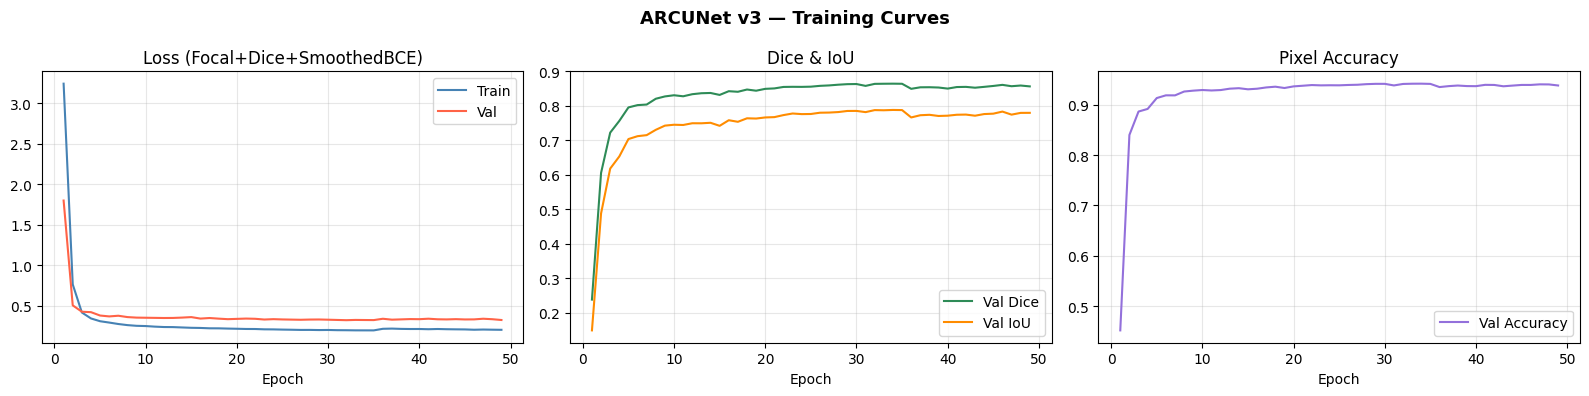

Saved → outputs/arcunet_train2_training_curves.png


In [ ]:
epochs_x = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('ARCUNet v3 — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(epochs_x, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss (Focal+Dice+SmoothedBCE)')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history['val_dice'], label='Val Dice', color='seagreen')
axes[1].plot(epochs_x, history['val_iou'],  label='Val IoU',  color='darkorange')
axes[1].set_title('Dice & IoU')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_x, history['val_acc'], label='Val Accuracy', color='mediumpurple')
axes[2].set_title('Pixel Accuracy')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(OUTPUT_DIR, f'{IMG_TAG}_training_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {curves_path}')

## Cell 12 — Visual Predictions (TTA vs Single-pass comparison)

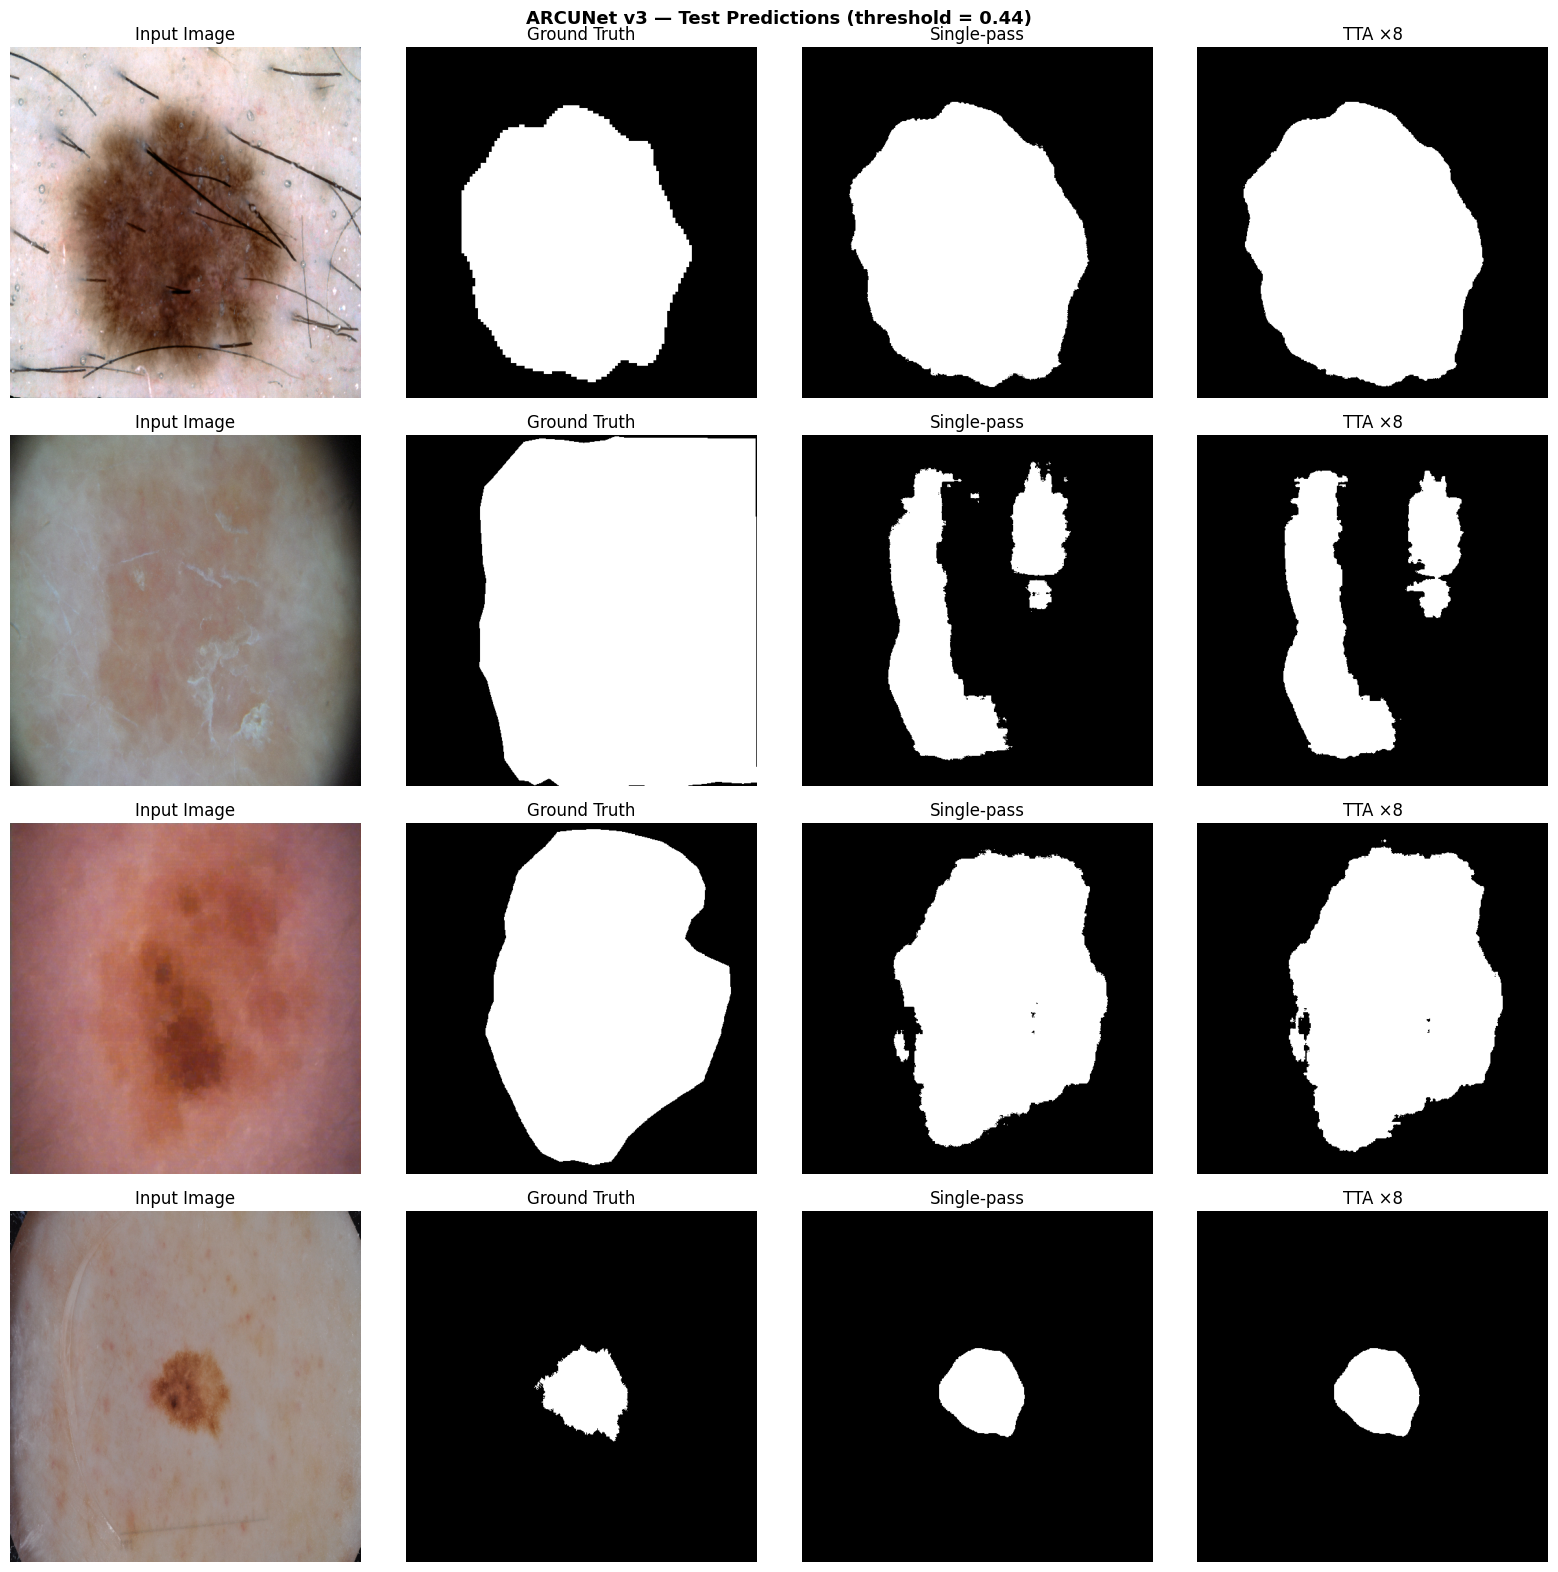

Saved → outputs/arcunet_train2_predictions.png


In [ ]:
from ARCUNet import predict_proba

model.eval()
imgs_vis, msks_vis = next(iter(test_loader))
imgs_vis = imgs_vis[:4]
msks_vis = msks_vis[:4]

std  = torch.tensor(IMAGENET_STD).view(3,1,1)
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)

# 4 columns: Input | Ground Truth | Single-pass | TTA
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('ARCUNet v3 — Test Predictions (threshold = {:.2f})'.format(BEST_THRESH),
             fontsize=13, fontweight='bold')

prob_tta_batch = tta_predict_batch(model, imgs_vis, DEVICE).cpu()

for i in range(4):
    img_disp  = (imgs_vis[i] * std + mean).permute(1,2,0).clamp(0,1).numpy()
    gt_disp   = msks_vis[i, 0].numpy()
    pred_sngl = (predict_proba(model, imgs_vis[i], device=str(DEVICE)) > BEST_THRESH).astype(float)
    pred_tta  = (prob_tta_batch[i, 0].numpy() > BEST_THRESH).astype(float)

    axes[i,0].imshow(img_disp);             axes[i,0].set_title('Input Image')
    axes[i,1].imshow(gt_disp,  cmap='gray'); axes[i,1].set_title('Ground Truth')
    axes[i,2].imshow(pred_sngl,cmap='gray'); axes[i,2].set_title('Single-pass')
    axes[i,3].imshow(pred_tta, cmap='gray'); axes[i,3].set_title('TTA ×8')

    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
preds_path = os.path.join(OUTPUT_DIR, f'{IMG_TAG}_predictions.png')
plt.savefig(preds_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {preds_path}')